In [5]:
import pandas as pd
import seaborn as sns

df = pd.read_csv(r'C:\Users\ayrto\Downloads\ProeyctoFCDIA\EDV_2020.csv', sep=';')

def limpiar_sentinela(df, columnas, valor):
    df[columnas] = df[columnas].replace(valor, pd.NA)

# Diccionario: valor centinela -> columnas
sentinelas = {
    99: [
        'niv_inst2','hijos_2','dia_nac2','mes_nac2',
        'niv_inst1','hijos_1','dia_nac1','cau_div','mes_nac1'
    ],
    9:  ['mcap_bie','nac_1','nac_2','sabe_leer1','sabe_leer2'],
    999: ['edad_1','edad_2'],
    9999: ['anio_nac1','anio_nac2']
}

# Aplicar limpieza
for valor, columnas in sentinelas.items():
    limpiar_sentinela(df, columnas, valor)

# Limpieza de columnas de fecha
columnas_fechas = [
    'fecha_insc','fecha_nac2','fecha_nac1','fecha_div','fecha_mat'
]
df[columnas_fechas] = df[columnas_fechas].replace(' ', pd.NA)

df = df.dropna().reset_index(drop=True)


Nueva Columna 'dia_sem_mat'

In [6]:
import pandas as pd

# Convertir a numérico
cols_fecha = ['dia_mat', 'mes_mat', 'anio_mat']
df[cols_fecha] = df[cols_fecha].apply(pd.to_numeric, errors='coerce')

# Crear fecha de matrimonio
df['fecha_mat'] = pd.to_datetime(
    df[['anio_mat', 'mes_mat', 'dia_mat']]
        .rename(columns={
            'anio_mat': 'year',
            'mes_mat': 'month',
            'dia_mat': 'day'
        }),
    errors='coerce'
)

# Día de la semana (lunes=1, ..., domingo=7)
df['dia_sem_mat'] = df['fecha_mat'].dt.weekday + 1



Inspección rápida

In [7]:
df.columns

Index(['prov_insc', 'cant_insc', 'parr_insc', 'anio_insc', 'mes_insc',
       'dia_insc', 'fecha_insc', 'anio_div', 'mes_div', 'dia_div', 'fecha_div',
       'anio_mat', 'mes_mat', 'dia_mat', 'fecha_mat', 'mcap_bie', 'dur_mat',
       'cau_div', 'nac_1', 'cod_pais1', 'sexo_1', 'anio_nac1', 'mes_nac1',
       'dia_nac1', 'fecha_nac1', 'edad_1', 'hijos_1', 'p_etnica1', 'niv_inst1',
       'sabe_leer1', 'prov_hab1', 'cant_hab1', 'parr_hab1', 'area_1', 'nac_2',
       'cod_pais2', 'sexo_2', 'anio_nac2', 'mes_nac2', 'dia_nac2',
       'fecha_nac2', 'edad_2', 'hijos_2', 'p_etnica2', 'niv_inst2',
       'sabe_leer2', 'prov_hab2', 'cant_hab2', 'parr_hab2', 'area_2',
       'dia_sem_mat'],
      dtype='object')

In [8]:
df.head()

,prov_insc,cant_insc,parr_insc,anio_insc,mes_insc,dia_insc,fecha_insc,anio_div,mes_div,dia_div,...,edad_2,hijos_2,p_etnica2,niv_inst2,sabe_leer2,prov_hab2,cant_hab2,parr_hab2,area_2,dia_sem_mat
0,9,901,90112,2020,7,30,7/30/2020,2020,6,30,...,65,0,6,7,1,9,901,90114,1,1
1,17,1701,170126,2020,1,21,1/21/2020,2019,9,2,...,44,1,7,7,1,88,8800,880000,1,4
2,9,901,90110,2020,9,22,9/22/2020,2018,8,19,...,52,6,6,6,1,9,901,90112,1,5
3,9,901,90110,2020,2,13,2/13/2020,2020,2,13,...,47,6,7,6,1,9,901,90114,1,2
4,17,1707,170750,2020,10,23,10/23/2020,2016,7,7,...,52,8,6,3,1,17,1707,170750,1,4


Selectivo por Días

In [9]:
dfGroup01 = df.groupby(['dia_sem_mat'])
dfGroup01['dur_mat'].describe()

,count,mean,std,min,25%,50%,75%,max
dia_sem_mat,,,,,,,,
1,1275.0,15.603137,10.753963,0.0,7.0,13.0,23.0,57.0
2,1290.0,14.948062,10.776361,0.0,6.0,12.0,22.0,55.0
3,1749.0,15.432247,11.271743,0.0,6.0,13.0,23.0,57.0
4,2138.0,14.315716,10.338625,0.0,6.0,12.0,21.0,64.0
5,4489.0,13.889508,9.700750,0.0,6.0,12.0,20.0,58.0
6,1143.0,17.511811,11.043521,0.0,9.0,16.0,24.0,55.0
7,241.0,21.601660,12.380724,0.0,13.0,19.0,30.0,60.0


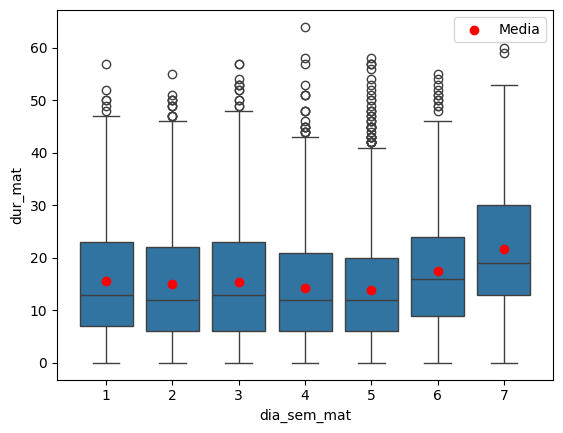

In [10]:
ax = sns.boxplot(
    data=df,
    x='dia_sem_mat',
    y='dur_mat'
)

medias = df.groupby('dia_sem_mat')['dur_mat'].mean()
ax.scatter(
    x=range(len(medias)),
    y=medias,
    color='red',
    zorder=3,
    label='Media'
)

ax.legend()



<Axes: xlabel='dia_sem_mat', ylabel='dur_mat'>

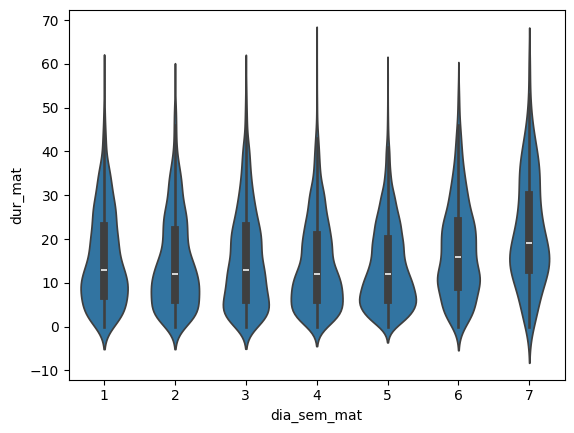

In [11]:
sns.violinplot(data=df, x='dia_sem_mat', y='dur_mat')

<Axes: xlabel='dia_sem_mat', ylabel='count'>

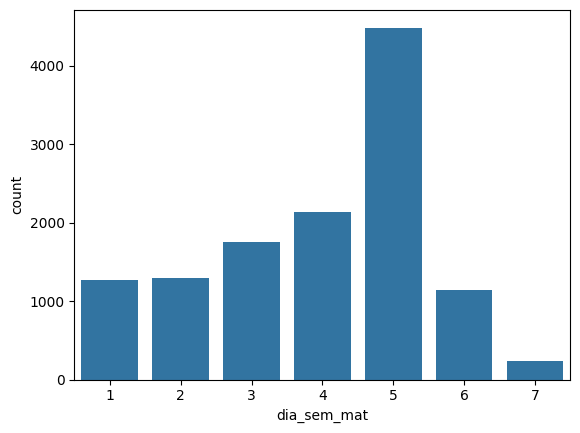

In [12]:
import seaborn as sns
sns.countplot(data=df,x='dia_sem_mat')

Selectivo por FindeSemana


<Axes: xlabel='tipo_dia', ylabel='dur_mat'>

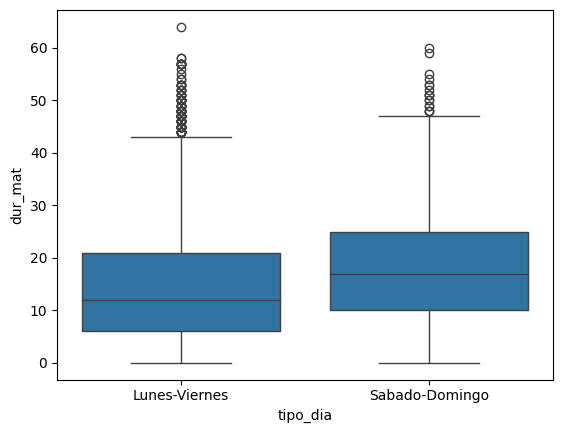

In [13]:
df['tipo_dia'] = df['dia_sem_mat'].apply(
    lambda x: 'Lunes-Viernes' if x in [1, 2, 3, 4, 5] else 'Sabado-Domingo'
)
sns.boxplot(data=df, x='tipo_dia', y='dur_mat')


<Axes: xlabel='tipo_dia', ylabel='dur_mat'>

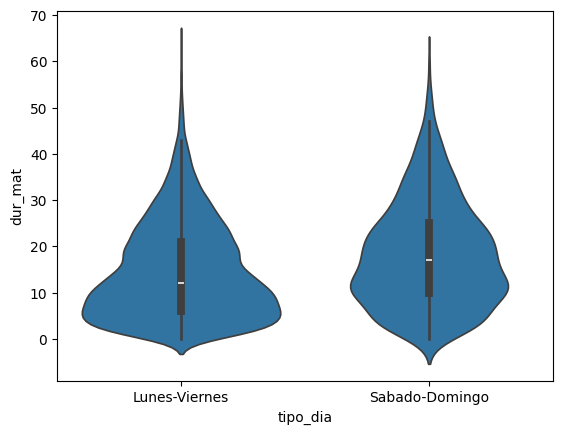

In [14]:
sns.violinplot(data=df, x='tipo_dia', y='dur_mat')

Selectivo por meses

<Axes: xlabel='mes_mat', ylabel='count'>

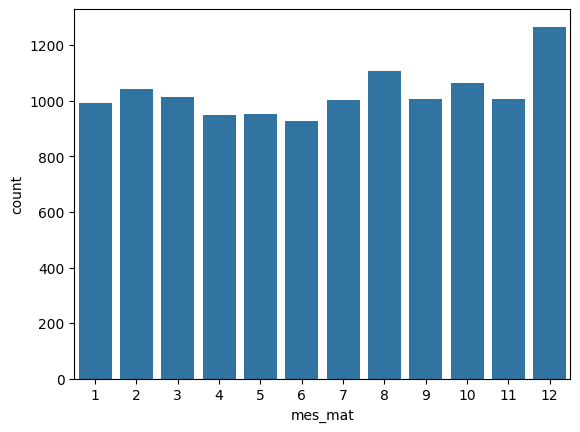

In [15]:
sns.countplot(data=df,x='mes_mat')

In [16]:
dfGroup02 = df.groupby(['mes_mat'])
dfGroup02['dur_mat'].describe()

,count,mean,std,min,25%,50%,75%,max
mes_mat,,,,,,,,
1,991.0,15.243189,10.510139,0.0,7.0,13.0,22.0,55.0
2,1041.0,14.195965,9.873918,0.0,7.0,13.0,21.0,58.0
3,1015.0,14.419704,10.172342,0.0,6.0,12.0,21.0,51.0
4,949.0,15.185458,10.650437,0.0,6.0,13.0,22.0,56.0
5,952.0,15.053571,10.861148,0.0,6.0,12.0,22.0,60.0
6,927.0,15.371090,10.388685,0.0,7.0,13.0,23.0,59.0
7,1002.0,14.914172,10.778518,0.0,6.0,12.0,22.0,57.0
8,1108.0,14.589350,10.465936,0.0,6.0,12.0,22.0,57.0
9,1005.0,15.663682,10.818786,0.0,7.0,14.0,23.0,64.0


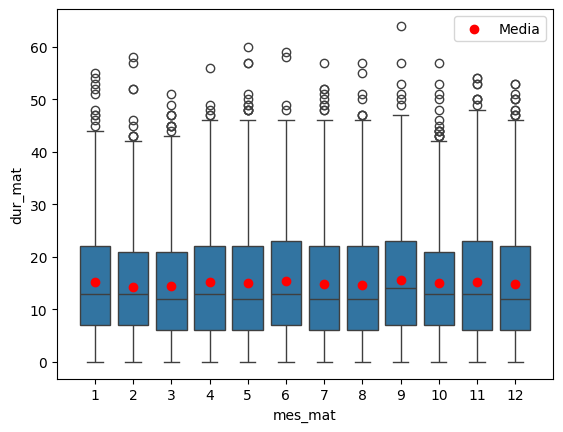

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(
    data=df,
    x='mes_mat',
    y='dur_mat'
)

# Calcular medias por mes (ordenadas)
medias = df.groupby('mes_mat')['dur_mat'].mean().sort_index()

ax.scatter(
    x=range(len(medias)),
    y=medias,
    color='red',
    zorder=3,
    label='Media'
)

ax.legend()
plt.show()


Nivel de educación - Número de hijos

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. Filtrar solo las parejas con mismo nivel educativo
df_mismo_nivel = df[df['niv_inst1'] == df['niv_inst2']].copy()

# 2. Calcular total de hijos por pareja
df_mismo_nivel['total_hijos'] = df_mismo_nivel['hijos_1'] + df_mismo_nivel['hijos_2']

# 3. Crear categoría según nivel educativo
def categorizar_nivel(nivel):
    """Categoriza el nivel educativo en Básica o Posgrado"""
    if 1 <= nivel <= 4:
        return 'Hasta educación básica'
    elif 5 <= nivel <= 9:
        return 'Hasta Posgrado'
    else:
        return 'Otro'

df_mismo_nivel['categoria_edu'] = df_mismo_nivel['niv_inst1'].apply(categorizar_nivel)

# 4. Filtrar solo las dos categorías que nos interesan
df_filtrado = df_mismo_nivel[df_mismo_nivel['categoria_edu'].isin(['Hasta educación básica', 'Hasta Posgrado'])]

# 5. Ver estadísticas descriptivas
print("=== ESTADÍSTICAS DE HIJOS POR CATEGORÍA ===")
print("=" * 60)

for categoria in ['Hasta educación básica', 'Hasta Posgrado']:
    subset = df_filtrado[df_filtrado['categoria_edu'] == categoria]
    print(f"\n{categoria.upper()}:")
    print(f"  Número de parejas: {len(subset):,}")
    print(f"  Niveles incluidos: {sorted(subset['niv_inst1'].unique())}")
    print(f"  Total de hijos: {subset['total_hijos'].sum():,}")
    print(f"  Promedio de hijos por pareja: {subset['total_hijos'].mean():.2f}")
    print(f"  Mediana de hijos: {subset['total_hijos'].median():.1f}")
    print(f"  Mínimo de hijos: {subset['total_hijos'].min():.0f}")
    print(f"  Máximo de hijos: {subset['total_hijos'].max():.0f}")
    print(f"  Desviación estándar: {subset['total_hijos'].std():.2f}")

print(f"\n{' RESUMÉN ':=^60}")
print(f"Total parejas analizadas: {len(df_filtrado):,}")
print(f"Total hijos registrados: {df_filtrado['total_hijos'].sum():,}")
print(f"Promedio general: {df_filtrado['total_hijos'].mean():.2f} hijos/pareja")

=== ESTADÍSTICAS DE HIJOS POR CATEGORÍA ===

HASTA EDUCACIÓN BÁSICA:
  Número de parejas: 1,577
  Niveles incluidos: [1, 2, 3, 4]
  Total de hijos: 1,327
  Promedio de hijos por pareja: 0.84
  Mediana de hijos: 0.0
  Mínimo de hijos: 0
  Máximo de hijos: 10
  Desviación estándar: 1.10

HASTA POSGRADO:
  Número de parejas: 6,371
  Niveles incluidos: [5, 6, 7, 8, 9]
  Total de hijos: 5,471
  Promedio de hijos por pareja: 0.86
  Mediana de hijos: 1.0
  Mínimo de hijos: 0
  Máximo de hijos: 8
  Desviación estándar: 1.02

========================= RESUMÉN ==========================
Total parejas analizadas: 7,948
Total hijos registrados: 6,798
Promedio general: 0.86 hijos/pareja


C:\Users\ayrto\AppData\Local\Temp\ipykernel_6548\2952140391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado,


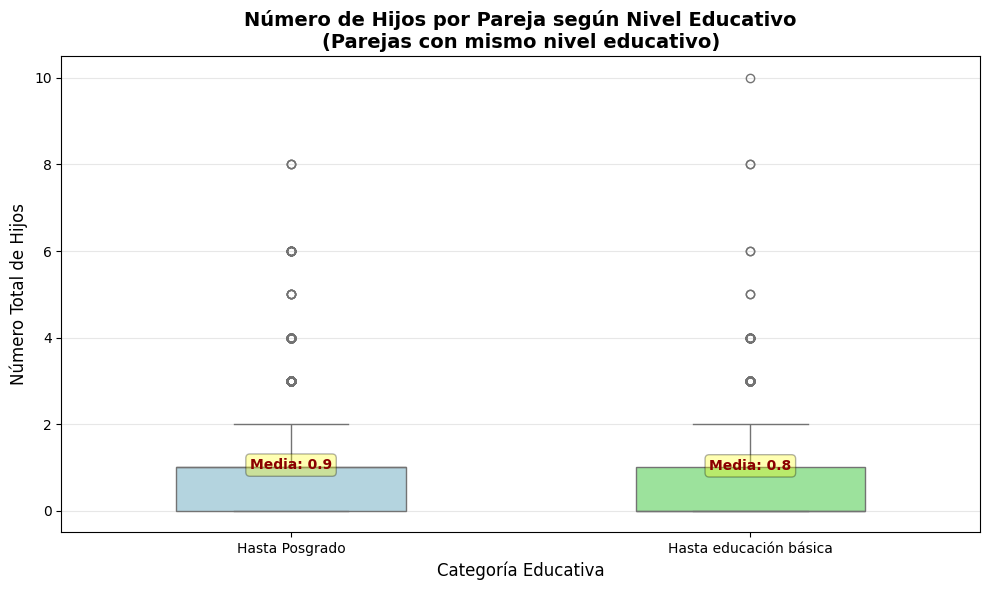

In [19]:
# Boxplot básico
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_filtrado,
            x='categoria_edu',
            y='total_hijos',
            palette=['lightblue', 'lightgreen'],
            width=0.5)

plt.title('Número de Hijos por Pareja según Nivel Educativo\n(Parejas con mismo nivel educativo)',
          fontsize=14, fontweight='bold')
plt.xlabel('Categoría Educativa', fontsize=12)
plt.ylabel('Número Total de Hijos', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Agregar medias
medias = df_filtrado.groupby('categoria_edu')['total_hijos'].mean()
for i, (cat, media) in enumerate(medias.items()):
    plt.text(i, media + 0.1, f'Media: {media:.1f}',
             ha='center', fontweight='bold', color='darkred',
             bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.3))

plt.tight_layout()
plt.show()

C:\Users\ayrto\AppData\Local\Temp\ipykernel_6548\2460482176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado,
C:\Users\ayrto\AppData\Local\Temp\ipykernel_6548\2460482176.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_filtrado,


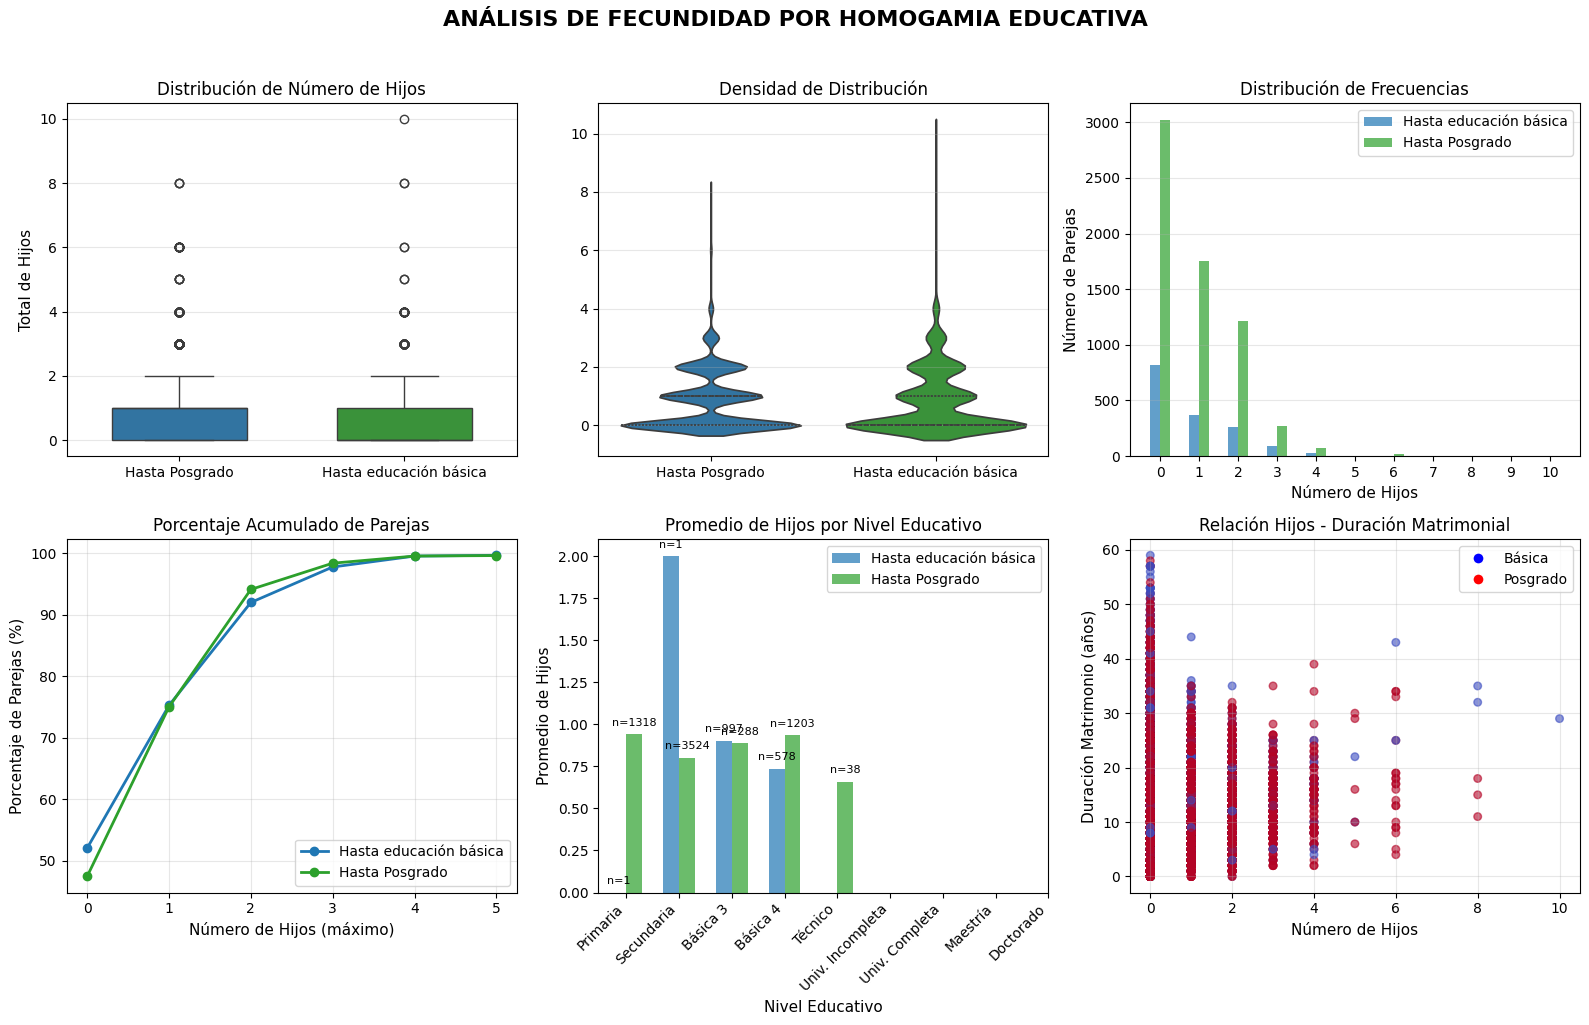

In [20]:
# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Boxplot principal
sns.boxplot(data=df_filtrado,
            x='categoria_edu',
            y='total_hijos',
            ax=axes[0, 0],
            palette=['#1f77b4', '#2ca02c'],
            width=0.6)
axes[0, 0].set_title('Distribución de Número de Hijos', fontsize=12)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Total de Hijos', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Violin plot
sns.violinplot(data=df_filtrado,
               x='categoria_edu',
               y='total_hijos',
               ax=axes[0, 1],
               palette=['#1f77b4', '#2ca02c'],
               inner='quartile')
axes[0, 1].set_title('Densidad de Distribución', fontsize=12)
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Conteo de parejas por número de hijos (barras apiladas)
max_hijos = int(df_filtrado['total_hijos'].max())
bins = list(range(0, max_hijos + 2))

for i, categoria in enumerate(['Hasta educación básica', 'Hasta Posgrado']):
    subset = df_filtrado[df_filtrado['categoria_edu'] == categoria]
    counts, _ = np.histogram(subset['total_hijos'], bins=bins)

    x_pos = np.arange(len(bins)-1) + i * 0.25
    axes[0, 2].bar(x_pos, counts, width=0.25,
                  label=categoria,
                  alpha=0.7,
                  color=['#1f77b4', '#2ca02c'][i])

axes[0, 2].set_title('Distribución de Frecuencias', fontsize=12)
axes[0, 2].set_xlabel('Número de Hijos', fontsize=11)
axes[0, 2].set_ylabel('Número de Parejas', fontsize=11)
axes[0, 2].legend()
axes[0, 2].set_xticks(np.arange(len(bins)-1) + 0.125)
axes[0, 2].set_xticklabels([f'{i}' for i in bins[:-1]])
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Porcentaje acumulado
for i, categoria in enumerate(['Hasta educación básica', 'Hasta Posgrado']):
    subset = df_filtrado[df_filtrado['categoria_edu'] == categoria]

    # Calcular porcentaje acumulado
    total = len(subset)
    acumulado = []
    for hijos in range(0, 6):  # De 0 a 5 hijos
        porcentaje = (subset['total_hijos'] <= hijos).sum() / total * 100
        acumulado.append(porcentaje)

    axes[1, 0].plot(range(0, 6), acumulado,
                   marker='o',
                   label=categoria,
                   linewidth=2,
                   color=['#1f77b4', '#2ca02c'][i])

axes[1, 0].set_title('Porcentaje Acumulado de Parejas', fontsize=12)
axes[1, 0].set_xlabel('Número de Hijos (máximo)', fontsize=11)
axes[1, 0].set_ylabel('Porcentaje de Parejas (%)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xticks(range(0, 6))

# 5. Distribución por nivel específico dentro de cada categoría
categorias = ['Hasta educación básica', 'Hasta Posgrado']
nombres_niveles = {
    1: 'Primaria', 2: 'Secundaria', 3: 'Básica 3', 4: 'Básica 4',
    5: 'Técnico', 6: 'Univ. Incompleta', 7: 'Univ. Completa',
    8: 'Maestría', 9: 'Doctorado'
}

for idx, categoria in enumerate(categorias):
    subset = df_filtrado[df_filtrado['categoria_edu'] == categoria]

    # Agrupar por nivel y calcular media de hijos
    medias_por_nivel = subset.groupby('niv_inst1')['total_hijos'].mean()

    x_pos = np.arange(len(medias_por_nivel)) + idx * 0.3
    axes[1, 1].bar(x_pos, medias_por_nivel.values,
                  width=0.3,
                  label=categoria,
                  color=['#1f77b4', '#2ca02c'][idx],
                  alpha=0.7)

    # Agregar etiquetas con número de parejas
    for j, (nivel, media) in enumerate(medias_por_nivel.items()):
        n_parejas = len(subset[subset['niv_inst1'] == nivel])
        axes[1, 1].text(x_pos[j], media + 0.05,
                       f'n={n_parejas}',
                       ha='center',
                       fontsize=8,
                       rotation=0)

axes[1, 1].set_title('Promedio de Hijos por Nivel Educativo', fontsize=12)
axes[1, 1].set_xlabel('Nivel Educativo', fontsize=11)
axes[1, 1].set_ylabel('Promedio de Hijos', fontsize=11)
axes[1, 1].legend()

# Configurar etiquetas del eje X
all_levels_basica = df_filtrado[df_filtrado['categoria_edu'] == 'Hasta educación básica']['niv_inst1'].unique()
all_levels_posgrado = df_filtrado[df_filtrado['categoria_edu'] == 'Hasta Posgrado']['niv_inst1'].unique()

# Combinar y ordenar
all_levels = sorted(set(list(all_levels_basica) + list(all_levels_posgrado)))
nombres = [nombres_niveles.get(n, f'Nivel {n}') for n in all_levels]
axes[1, 1].set_xticks(np.arange(len(all_levels)) + 0.15)
axes[1, 1].set_xticklabels(nombres, rotation=45, ha='right')

# 6. Scatter plot: hijos vs duración del matrimonio (si quieres ver relación)
scatter = axes[1, 2].scatter(df_filtrado['total_hijos'],
                            df_filtrado['dur_mat'],
                            c=df_filtrado['categoria_edu'].map({'Hasta educación básica': 0, 'Hasta Posgrado': 1}),
                            cmap='coolwarm',
                            alpha=0.6,
                            s=30)

axes[1, 2].set_title('Relación Hijos - Duración Matrimonial', fontsize=12)
axes[1, 2].set_xlabel('Número de Hijos', fontsize=11)
axes[1, 2].set_ylabel('Duración Matrimonio (años)', fontsize=11)
axes[1, 2].grid(alpha=0.3)

# Crear leyenda personalizada para el scatter
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='blue', markersize=8, label='Básica'),
                   Line2D([0], [0], marker='o', color='w',
                         markerfacecolor='red', markersize=8, label='Posgrado')]
axes[1, 2].legend(handles=legend_elements)

plt.suptitle('ANÁLISIS DE FECUNDIDAD POR HOMOGAMIA EDUCATIVA',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. Calcular total de hijos por pareja
df['total_hijos'] = df['hijos_1'] + df['hijos_2']

# 2. Crear categoría según presencia de hijos
df['tiene_hijos'] = df['total_hijos'].apply(lambda x: 'Con hijos' if x >= 1 else 'Sin hijos')

# 3. Filtrar datos (todas las parejas)
df_analisis = df.copy()

# 4. Estadísticas descriptivas
print("=== ESTADÍSTICAS DURACIÓN MATRIMONIAL POR PRESENCIA DE HIJOS ===")
print("=" * 70)

categorias = ['Sin hijos', 'Con hijos']
estadisticas = []

for categoria in categorias:
    subset = df_analisis[df_analisis['tiene_hijos'] == categoria]

    stats_dict = {
        'Categoría': categoria,
        'N_Parejas': len(subset),
        'Porcentaje': len(subset) / len(df_analisis) * 100,
        'Media_Duración': subset['dur_mat'].mean(),
        'Mediana_Duración': subset['dur_mat'].median(),
        'Min_Duración': subset['dur_mat'].min(),
        'Max_Duración': subset['dur_mat'].max(),
        'Std_Duración': subset['dur_mat'].std(),
        'Media_Hijos': subset['total_hijos'].mean() if categoria == 'Con hijos' else 0
    }
    estadisticas.append(stats_dict)

    print(f"\n{categoria.upper()}:")
    print(f"  Número de parejas: {len(subset):,}")
    print(f"  Porcentaje del total: {len(subset)/len(df_analisis)*100:.1f}%")
    print(f"  Duración promedio: {subset['dur_mat'].mean():.2f} años")
    print(f"  Duración mediana: {subset['dur_mat'].median():.2f} años")
    print(f"  Rango: [{subset['dur_mat'].min():.1f}, {subset['dur_mat'].max():.1f}] años")
    if categoria == 'Con hijos':
        print(f"  Promedio de hijos: {subset['total_hijos'].mean():.2f}")
        print(f"  Distribución de hijos:")
        for i in range(1, int(subset['total_hijos'].max()) + 1):
            n_parejas = (subset['total_hijos'] == i).sum()
            if n_parejas > 0:
                print(f"    {i} hijo(s): {n_parejas:,} parejas ({n_parejas/len(subset)*100:.1f}%)")

df_stats = pd.DataFrame(estadisticas)
print(f"\n{' RESUMÉN GENERAL ':=^70}")
print(f"Total parejas analizadas: {len(df_analisis):,}")
print(f"Duración promedio general: {df_analisis['dur_mat'].mean():.2f} años")
print(f"Diferencia de medias: {df_stats.loc[1, 'Media_Duración'] - df_stats.loc[0, 'Media_Duración']:.2f} años")

=== ESTADÍSTICAS DURACIÓN MATRIMONIAL POR PRESENCIA DE HIJOS ===

SIN HIJOS:
  Número de parejas: 5,816
  Porcentaje del total: 47.2%
  Duración promedio: 17.85 años
  Duración mediana: 18.00 años
  Rango: [0.0, 64.0] años

CON HIJOS:
  Número de parejas: 6,509
  Porcentaje del total: 52.8%
  Duración promedio: 12.37 años
  Duración mediana: 11.00 años
  Rango: [0.0, 51.0] años
  Promedio de hijos: 1.66
  Distribución de hijos:
    1 hijo(s): 3,371 parejas (51.8%)
    2 hijo(s): 2,337 parejas (35.9%)
    3 hijo(s): 568 parejas (8.7%)
    4 hijo(s): 170 parejas (2.6%)
    5 hijo(s): 15 parejas (0.2%)
    6 hijo(s): 37 parejas (0.6%)
    7 hijo(s): 1 parejas (0.0%)
    8 hijo(s): 8 parejas (0.1%)
    10 hijo(s): 1 parejas (0.0%)
    12 hijo(s): 1 parejas (0.0%)

========================== RESUMÉN GENERAL ===========================
Total parejas analizadas: 12,325
Duración promedio general: 14.96 años
Diferencia de medias: -5.48 años


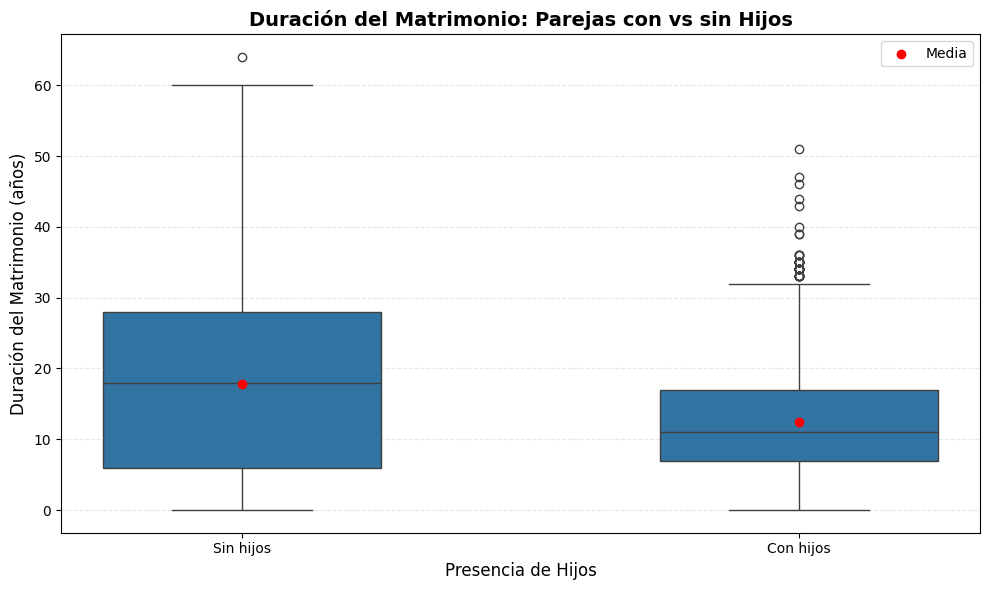

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

orden = ['Sin hijos', 'Con hijos']

sns.boxplot(
    data=df_analisis,
    x='tiene_hijos',
    y='dur_mat',
    order=orden,
    width=0.5,
    ax=ax
)

# Medias
medias = (
    df_analisis
    .groupby('tiene_hijos')['dur_mat']
    .mean()
    .reindex(orden)
)

ax.scatter(
    x=range(len(medias)),
    y=medias,
    color='red',
    zorder=3,
    label='Media'
)

# Etiquetas y estilo
ax.set_title(
    'Duración del Matrimonio: Parejas con vs sin Hijos',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Presencia de Hijos', fontsize=12)
ax.set_ylabel('Duración del Matrimonio (años)', fontsize=12)

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [23]:
# Crear una tabla de contingencia para entender los datos
contingency = pd.crosstab(df['niv_inst1'], df['niv_inst2'])
print("TABLA DE CONTINGENCIA (niv_inst1 × niv_inst2):")
print(contingency)

# Ver para un nivel específico
nivel = 5
print(f"\nPara niv_inst1 = {nivel}:")
print(f"Distribución de niv_inst2: {dict(contingency.loc[nivel])}")

# Ver estadísticas generales
print(f"\nESTADÍSTICAS:")
print(f"Total de registros: {len(df)}")
print(f"Valores únicos niv_inst1: {sorted(df['niv_inst1'].unique())}")
print(f"Valores únicos niv_inst2: {sorted(df['niv_inst2'].unique())}")


TABLA DE CONTINGENCIA (niv_inst1 × niv_inst2):
niv_inst2  0  1  2    3    4     5     6    7     8   9
niv_inst1                                              
0          4  2  0    3    8     0     1    1     1   0
1          0  1  0    3    2     1     3    0     0   0
2          1  0  1    1    2     1     1    0     1   0
3          7  1  1  997   56   212   155   10    52   1
4          7  3  2   59  578    81   277   25    62   2
5          1  0  0  153   71  1318   255   43   234   7
6          2  2  4   86  235   178  3524  252   528  20
7          0  0  0    6   11    52   176  288   140   9
8          1  1  0   19   28   172   385  133  1203  44
9          0  0  0    3    2     3    15    7    50  38

Para niv_inst1 = 5:
Distribución de niv_inst2: {0: np.int64(1), 1: np.int64(0), 2: np.int64(0), 3: np.int64(153), 4: np.int64(71), 5: np.int64(1318), 6: np.int64(255), 7: np.int64(43), 8: np.int64(234), 9: np.int64(7)}

ESTADÍSTICAS:
Total de registros: 12325
Valores únicos niv_i

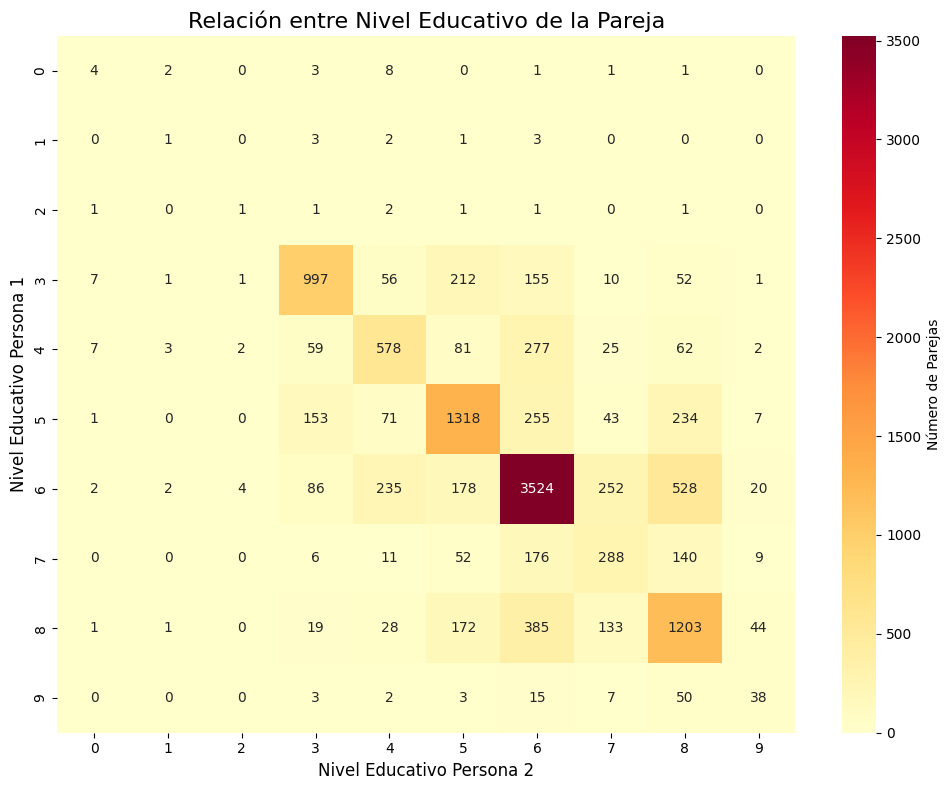

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear tabla de contingencia
contingency = pd.crosstab(df['niv_inst1'], df['niv_inst2'])

# 2. Heatmap básico
plt.figure(figsize=(10, 8))
sns.heatmap(contingency,
            annot=True,        # Mostrar números
            fmt='d',           # Formato entero
            cmap='YlOrRd',     # Paleta de colores
            cbar_kws={'label': 'Número de Parejas'})

plt.title('Relación entre Nivel Educativo de la Pareja', fontsize=16)
plt.xlabel('Nivel Educativo Persona 2', fontsize=12)
plt.ylabel('Nivel Educativo Persona 1', fontsize=12)
plt.tight_layout()
plt.show()

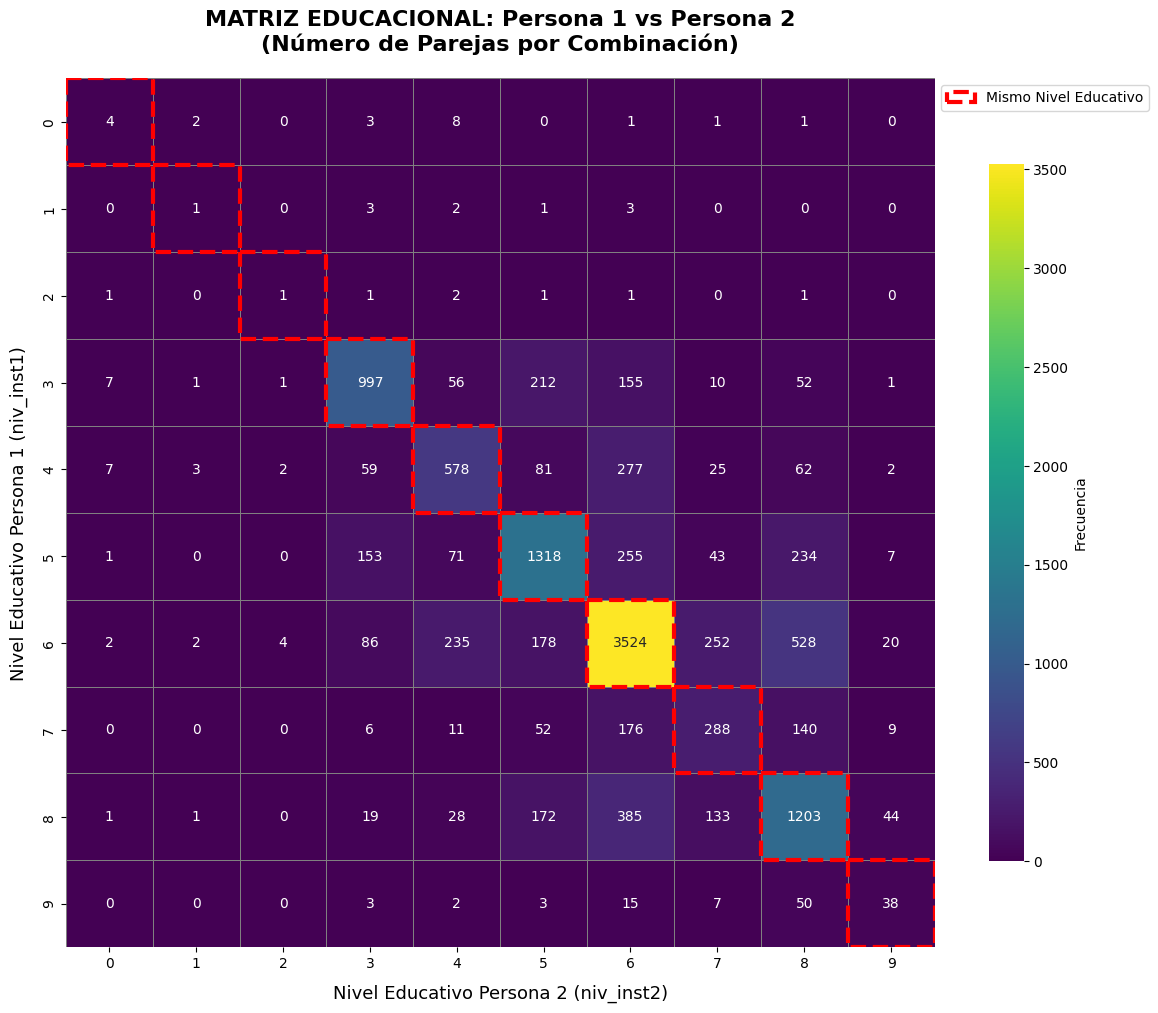

In [25]:
# Calcular tabla de contingencia
contingency = pd.crosstab(df['niv_inst1'], df['niv_inst2'])

# Crear figura
plt.figure(figsize=(12, 10))

# Heatmap con más opciones
ax = sns.heatmap(contingency,
                 annot=True,
                 fmt='d',
                 cmap='viridis',
                 linewidths=0.5,
                 linecolor='gray',
                 square=True,
                 cbar_kws={'shrink': 0.8, 'label': 'Frecuencia'},
                 annot_kws={'size': 10})

# Personalizar
plt.title('MATRIZ EDUCACIONAL: Persona 1 vs Persona 2\n(Número de Parejas por Combinación)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nivel Educativo Persona 2 (niv_inst2)', fontsize=13, labelpad=10)
plt.ylabel('Nivel Educativo Persona 1 (niv_inst1)', fontsize=13, labelpad=10)

# Resaltar diagonal (parejas con mismo nivel educativo)
for i in range(len(contingency)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                              fill=False,
                              edgecolor='red',
                              linewidth=3,
                              linestyle='--'))

# Leyenda para la diagonal
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor='red',
                        linewidth=3, linestyle='--',
                        label='Mismo Nivel Educativo')]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

=== ESTADÍSTICAS POR CATEGORÍA ===
--------------------------------------------------

Hasta educación básica:
  Número de parejas: 1,577
  Niveles incluidos: [1, 2, 3, 4]
  Duración promedio: 20.57 años
  Duración mediana: 20.00 años
  Duración mínima: 0.00 años
  Duración máxima: 59.00 años

Hasta Posgrado:
  Número de parejas: 6,371
  Niveles incluidos: [5, 6, 7, 8, 9]
  Duración promedio: 13.91 años
  Duración mediana: 12.00 años
  Duración mínima: 0.00 años
  Duración máxima: 58.00 años

Total parejas analizadas: 7,948
Total parejas mismo nivel: 7,952
Proporción analizada: 99.9%


C:\Users\ayrto\AppData\Local\Temp\ipykernel_6548\3254146194.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado,


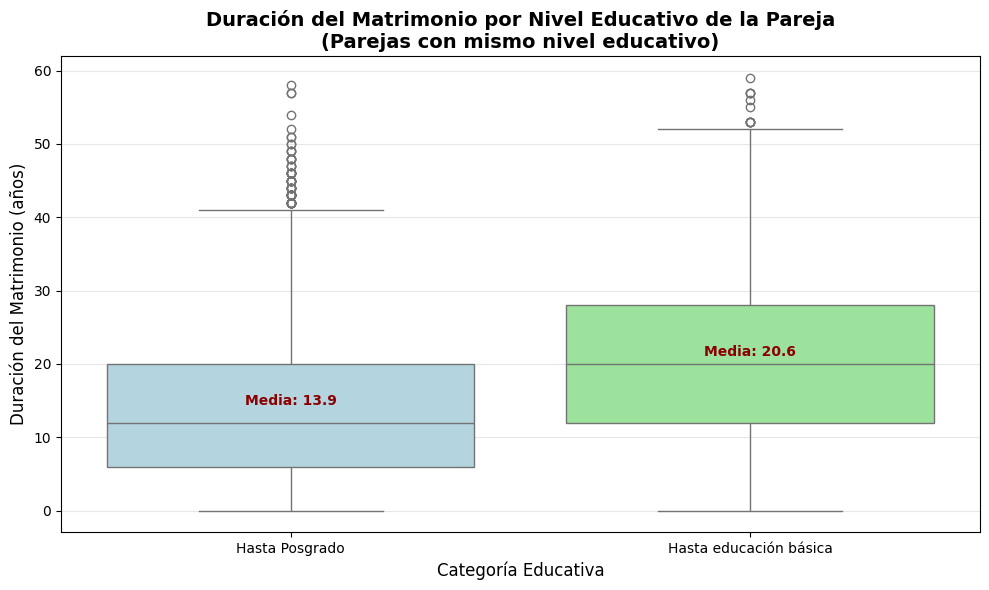

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtrar solo las parejas con mismo nivel educativo
df_mismo_nivel = df[df['niv_inst1'] == df['niv_inst2']].copy()

# 2. Crear nueva categoría según nivel educativo
def categorizar_nivel(nivel):
    """Categoriza el nivel educativo en Básica o Posgrado"""
    if 1 <= nivel <= 4:
        return 'Hasta educación básica'
    elif 5 <= nivel <= 9:
        return 'Hasta Posgrado'
    else:
        return 'Otro'  # Para nivel 0 u otros

# Aplicar categorización
df_mismo_nivel['categoria_edu'] = df_mismo_nivel['niv_inst1'].apply(categorizar_nivel)

# 3. Filtrar solo las dos categorías que nos interesan
df_filtrado = df_mismo_nivel[df_mismo_nivel['categoria_edu'].isin(['Hasta educación básica', 'Hasta Posgrado'])]

# 4. Ver estadísticas descriptivas
print("=== ESTADÍSTICAS POR CATEGORÍA ===")
print("-" * 50)

for categoria in ['Hasta educación básica', 'Hasta Posgrado']:
    subset = df_filtrado[df_filtrado['categoria_edu'] == categoria]
    print(f"\n{categoria}:")
    print(f"  Número de parejas: {len(subset):,}")
    print(f"  Niveles incluidos: {sorted(subset['niv_inst1'].unique())}")
    print(f"  Duración promedio: {subset['dur_mat'].mean():.2f} años")
    print(f"  Duración mediana: {subset['dur_mat'].median():.2f} años")
    print(f"  Duración mínima: {subset['dur_mat'].min():.2f} años")
    print(f"  Duración máxima: {subset['dur_mat'].max():.2f} años")

print(f"\nTotal parejas analizadas: {len(df_filtrado):,}")
print(f"Total parejas mismo nivel: {len(df_mismo_nivel):,}")
print(f"Proporción analizada: {len(df_filtrado)/len(df_mismo_nivel)*100:.1f}%")

# 5. Boxplot básico
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtrado,
            x='categoria_edu',
            y='dur_mat',
            palette=['lightblue', 'lightgreen'])

plt.title('Duración del Matrimonio por Nivel Educativo de la Pareja\n(Parejas con mismo nivel educativo)',
          fontsize=14, fontweight='bold')
plt.xlabel('Categoría Educativa', fontsize=12)
plt.ylabel('Duración del Matrimonio (años)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Agregar media
medias = df_filtrado.groupby('categoria_edu')['dur_mat'].mean()
for i, (cat, media) in enumerate(medias.items()):
    plt.text(i, media + 0.5, f'Media: {media:.1f}',
             ha='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

Filtro boxplot por nivel insitucional según número de hijos entre la pareja

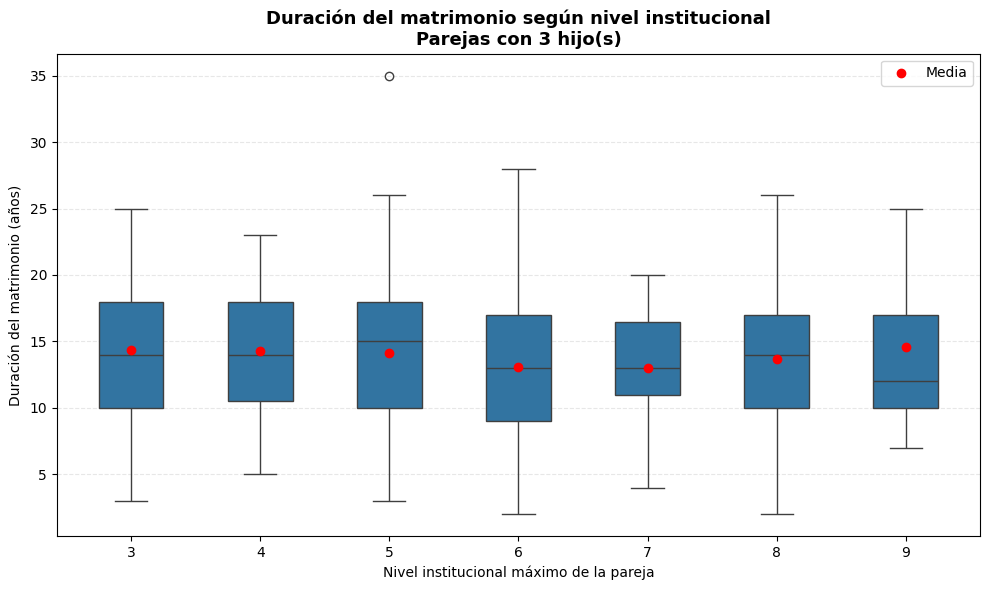

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Preparación de datos ---
df_plot = df.copy()

df_plot["hijos_totales"] = df_plot["hijos_1"] + df_plot["hijos_2"]
df_plot["niv_inst_pareja"] = df_plot[["niv_inst1", "niv_inst2"]].max(axis=1)

df_plot = df_plot.dropna(
    subset=["hijos_totales", "niv_inst_pareja", "dur_mat"]
)

# --- Input del usuario ---
hijos_input = int(input("Ingrese el número total de hijos de la pareja: "))

df_filtrado = df_plot[df_plot["hijos_totales"] == hijos_input]

if df_filtrado.empty:
    print(f"No existen parejas con {hijos_input} hijo(s).")
else:
    # --- Boxplot ---
    plt.figure(figsize=(10, 6))

    ax = sns.boxplot(
        data=df_filtrado,
        x="niv_inst_pareja",
        y="dur_mat",
        width=0.5
    )

    # Medias
    medias = (
        df_filtrado
        .groupby("niv_inst_pareja")["dur_mat"]
        .mean()
        .sort_index()
    )

    ax.scatter(
        range(len(medias)),
        medias,
        color="red",
        zorder=3,
        label="Media"
    )

    ax.set_title(
        f"Duración del matrimonio según nivel institucional\nParejas con {hijos_input} hijo(s)",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("Nivel institucional máximo de la pareja")
    ax.set_ylabel("Duración del matrimonio (años)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()



In [28]:
# Matriz nivel institucional vs número de hijos
matriz_conteo = pd.crosstab(
    index=df_plot["niv_inst_pareja"],
    columns=df_plot["hijos_totales"]
)

matriz_conteo



hijos_totales,0,1,2,3,4,5,6,7,8,10,12
niv_inst_pareja,,,,,,,,,,,
0,4,0,0,0,0,0,0,0,0,0,0
1,3,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,0
3,490,256,184,65,12,1,2,0,2,1,0
4,433,142,93,27,19,1,1,0,1,0,0
5,811,498,381,105,32,4,6,0,1,0,0
6,2401,1203,840,198,57,6,15,1,2,0,0
7,384,255,174,35,11,3,1,0,0,0,1
8,1198,964,621,129,36,0,10,0,2,0,0


Clustering


In [29]:
df['hijos_pareja'] = df['hijos_1'] + df['hijos_2']
df['niv_inst_pareja'] = df[['niv_inst1', 'niv_inst2']].max(axis=1)
s1 = df['sabe_leer1'].map({1:1, 2:0})
s2 = df['sabe_leer2'].map({1:1, 2:0})

df['sabe_leer_pareja'] = ((s1 + s2) >= 1).astype(int)



In [30]:
features_pareja = [
    'edad_1',
    'edad_2',
    'dur_mat',
    'hijos_pareja',
    'niv_inst_pareja',
    'sabe_leer_pareja'
]

df_clust = df[features_pareja].copy()
df_clust = df_clust.dropna()


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)


In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette[k] = silhouette_score(X_scaled, labels)

silhouette


{2: 0.3473938244038636,
 3: 0.2703997854161045,
 4: 0.24643185217975236,
 5: 0.2481739043491168,
 6: 0.2538508278132675}

In [33]:
kmeans = KMeans(n_clusters=6, random_state=42)
df_clust['cluster'] = kmeans.fit_predict(X_scaled)


In [34]:
perfil = df_clust.groupby('cluster').mean()
perfil


,edad_1,edad_2,dur_mat,hijos_pareja,niv_inst_pareja,sabe_leer_pareja
cluster,,,,,,
0,42.036422,39.270288,15.688179,1.023003,3.844728,1.0
1,32.537428,30.206745,5.914450,0.556622,6.773512,1.0
2,49.334142,45.936915,17.549393,0.346967,6.568804,1.0
3,60.219037,57.239679,32.684060,0.084289,5.240252,1.0
4,68.0,73.5,33.500000,0.0,0.0,0.0
5,38.565323,35.643548,12.282258,2.435484,6.519758,1.0


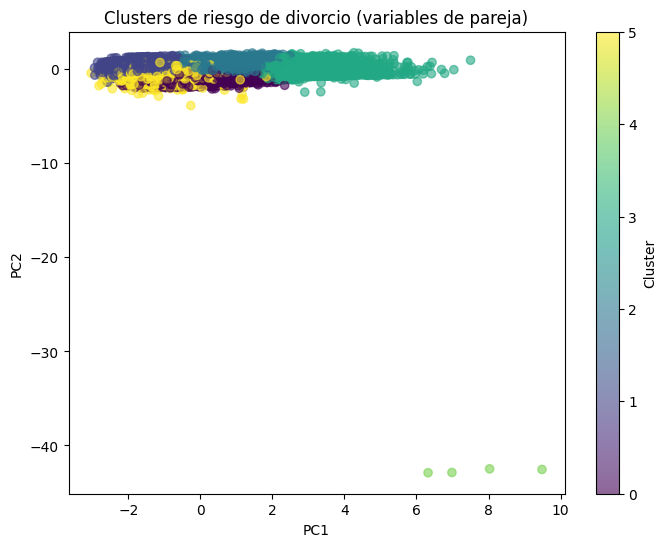

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clust['cluster'],
    alpha=0.6
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters de riesgo de divorcio (variables de pareja)')
plt.colorbar(label='Cluster')
plt.show()


In [36]:
import numpy as np

x = X_pca[:, 0]
y = X_pca[:, 1]

x_min, x_max = np.percentile(x, [2, 98])
y_min, y_max = np.percentile(y, [2, 98])


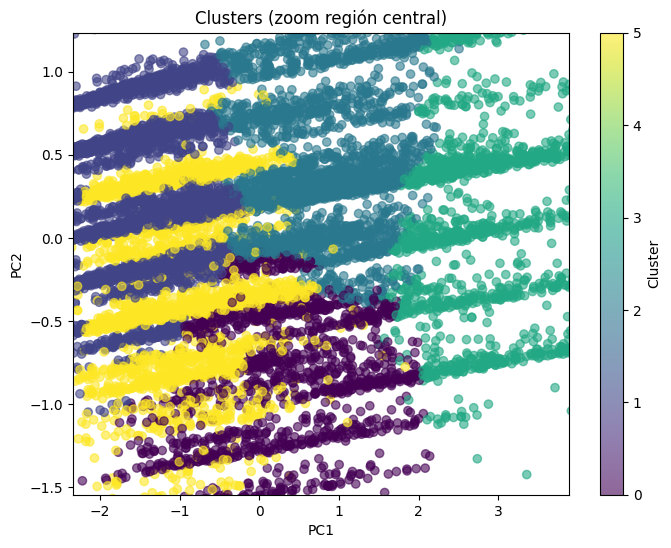

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(
    x,
    y,
    c=df_clust['cluster'],
    alpha=0.6
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters (zoom región central)')
plt.colorbar(label='Cluster')
plt.show()


Clustering 2

In [38]:
X = df.iloc[:, :-1].values
X


array([[9, 901, 90112, ..., 'Sin hijos', 0, 7],
       [17, 1701, 170126, ..., 'Con hijos', 2, 8],
       [9, 901, 90110, ..., 'Con hijos', 12, 7],
       ...,
       [12, 1205, 120502, ..., 'Sin hijos', 0, 3],
       [12, 1205, 120502, ..., 'Con hijos', 1, 6],
       [9, 901, 90112, ..., 'Sin hijos', 0, 6]],
      shape=(12325, 56), dtype=object)

In [39]:
features = [
    'edad_1',
    'edad_2',
    'dur_mat',
    'hijos_pareja',
    'niv_inst_pareja',
    'sabe_leer_pareja'
]

df_clust = df[features].dropna().copy()
X = df_clust.values


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)


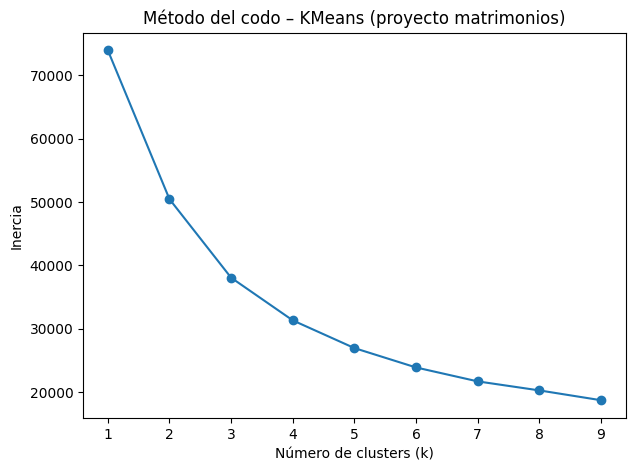

In [42]:
plt.figure(figsize=(7,5))
plt.plot(K, inercias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo – KMeans (proyecto matrimonios)')
plt.show()


In [43]:
kmeans = KMeans(
    n_clusters=3,
    random_state=3,
    n_init=10
)

df_clust['cluster'] = kmeans.fit_predict(X)


In [44]:
perfil_clusters = df_clust.groupby('cluster').mean()
perfil_clusters


,edad_1,edad_2,dur_mat,hijos_pareja,niv_inst_pareja,sabe_leer_pareja
cluster,,,,,,
0,39.991684,36.99406,13.692605,2.154737,5.700921,1.000000
1,54.643927,51.38531,25.110292,0.188258,5.629665,0.999049
2,34.345822,31.97832,6.862766,0.583456,6.756472,1.000000


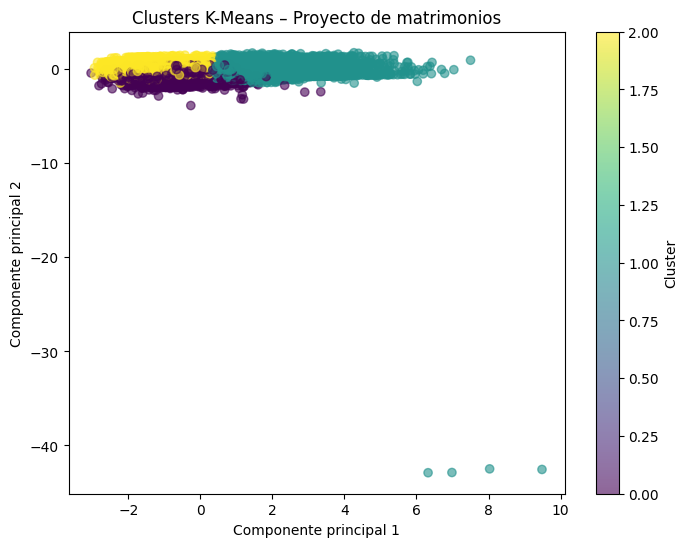

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clust['cluster'],
    alpha=0.6
)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clusters K-Means – Proyecto de matrimonios')
plt.colorbar(label='Cluster')
plt.show()
